<a href="https://colab.research.google.com/github/adithya0x/Optimal-Portfolio-Allocation/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [2]:
print("Fetching and Preprocessing Data...")
# Selected diverse assets: Tech, Healthcare, Energy, Bank, and Long-Term Treasury Bonds
TICKERS = ['AAPL', 'JNJ', 'XOM', 'JPM', 'TLT']
TRADING_DAYS = 252

df = yf.download(TICKERS, period="5y")

# Handle multi-index columns for yfinance
try:
    prices = df.xs('Close', axis=1, level=0)
except KeyError:
    prices = df['Close']

# Clean data and calculate metrics
prices = prices.ffill().dropna()
daily_returns = prices.pct_change().dropna()

mu = daily_returns.mean().values * TRADING_DAYS
Sigma = daily_returns.cov().values * TRADING_DAYS
n_assets = len(TICKERS)

# Align TICKERS with the column order fetched by yfinance (alphabetical)
TICKERS = list(daily_returns.columns)
print(f"Assets loaded: {TICKERS}\n")

Fetching and Preprocessing Data...


/tmp/ipykernel_6696/1149877595.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKERS, period="5y")
[*********************100%***********************]  5 of 5 completed

Assets loaded: ['AAPL', 'JNJ', 'JPM', 'TLT', 'XOM']



In [5]:
# Define CVXPY variables
w = cp.Variable(n_assets)
risk_aversion = cp.Parameter(nonneg=True) # This is our tunable lambda

# Expected Return = w^T * mu
expected_return = w @ mu
# Portfolio Variance = w^T * Sigma * w
portfolio_variance = cp.quad_form(w, Sigma)

# Objective: Maximize (Return - Lambda * Variance)
utility = expected_return - (risk_aversion * portfolio_variance)
objective = cp.Maximize(utility)

# Constraints: Fully invested, Long-only
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

prob = cp.Problem(objective, constraints)

In [4]:
print("Solving optimizations across varying risk aversion levels...")

# Create an array of 50 lambda values from highly risk-seeking (0.1) to highly risk-averse (50)
# We use logspace so the points cluster efficiently around the curve
lambda_values = np.logspace(-1, 1.7, 50)

weights_history = []
returns_history = []
volatility_history = []

for lam in lambda_values:
    risk_aversion.value = lam
    prob.solve()

    if prob.status == 'optimal':
        # Clean up near-zero float artifacts
        clean_weights = np.where(w.value < 1e-4, 0, w.value)

        weights_history.append(clean_weights)
        returns_history.append(expected_return.value)
        volatility_history.append(np.sqrt(portfolio_variance.value))

# Convert to Numpy Arrays for easier plotting
weights_matrix = np.array(weights_history)

print("Optimization complete.\n")

Solving optimizations across varying risk aversion levels...
Optimization complete.



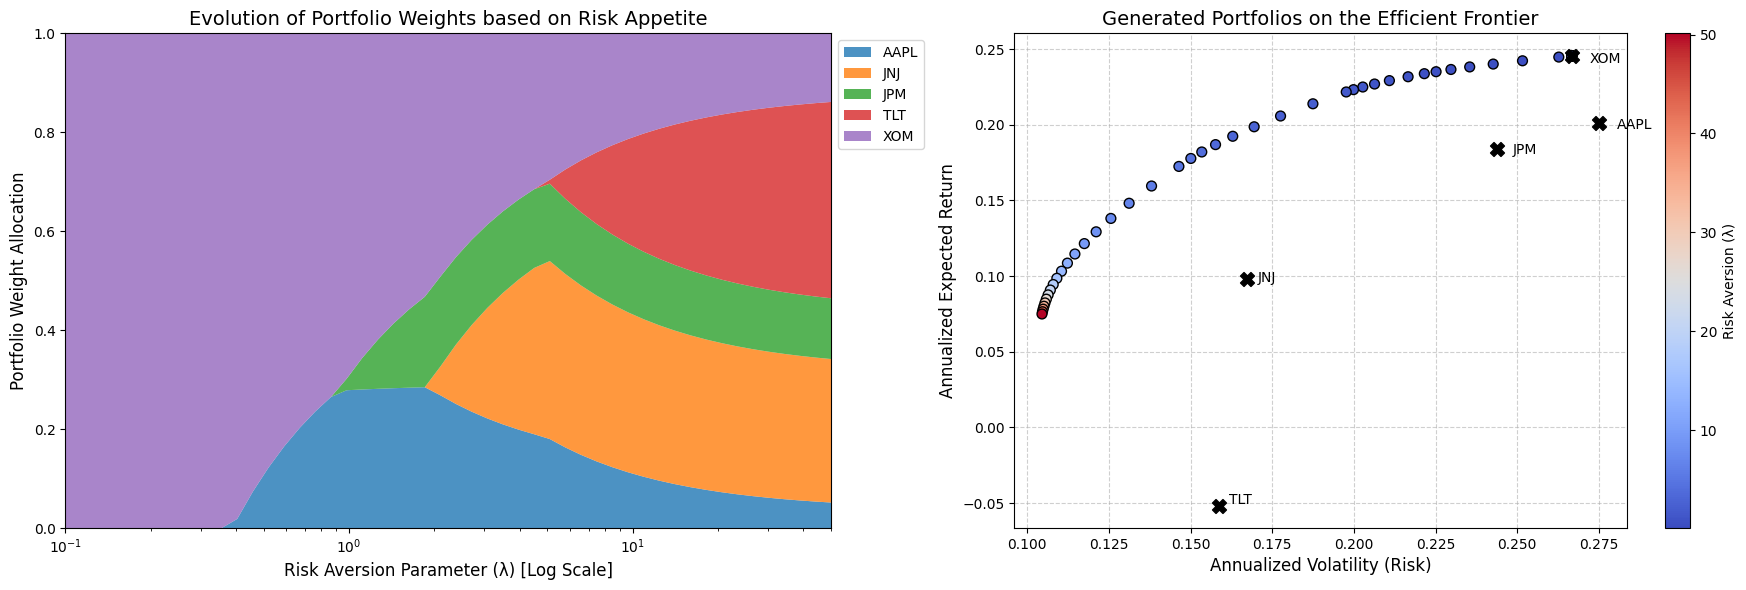

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ---- Plot 1: Portfolio Weights vs Risk Aversion (Lambda) ----
# Using a stackplot to visually represent asset allocation shifts
ax1.stackplot(lambda_values, weights_matrix.T, labels=TICKERS, alpha=0.8)
ax1.set_xscale('log') # Log scale because lambda spans orders of magnitude
ax1.set_xlabel("Risk Aversion Parameter (λ) [Log Scale]", fontsize=12)
ax1.set_ylabel("Portfolio Weight Allocation", fontsize=12)
ax1.set_title("Evolution of Portfolio Weights based on Risk Appetite", fontsize=14)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.margins(x=0, y=0)

# ---- Plot 2: Portfolios on the Efficient Frontier ----
# Plotting the optimized portfolios in Risk-Return space
scatter = ax2.scatter(volatility_history, returns_history, c=lambda_values, cmap='coolwarm', s=50, edgecolors='k', zorder=3)

# Add individual assets to the map for perspective
asset_vols = np.sqrt(np.diag(Sigma))
ax2.scatter(asset_vols, mu, color='black', marker='X', s=100, label='Individual Assets', zorder=4)
for i, txt in enumerate(TICKERS):
    ax2.annotate(txt, (asset_vols[i]*1.02, mu[i]*0.98), fontsize=10)

ax2.set_xlabel("Annualized Volatility (Risk)", fontsize=12)
ax2.set_ylabel("Annualized Expected Return", fontsize=12)
ax2.set_title("Generated Portfolios on the Efficient Frontier", fontsize=14)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Risk Aversion (λ)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()